In [3]:
from data_generators import get_wgan_data_generator,get_gt_data_generator
from opt_targeted_transfers import get_cond_density_estimator, Dataset, get_nll
from feature_selection import forward_selection
import matplotlib.pyplot as plt

In [2]:
gt_generator = get_gt_data_generator(trainpath='data/train.parquet')
train_df = gt_generator(10000, seed=123456)

(array([ 42., 286., 598., 800., 837., 847., 718., 784., 667., 541., 460.,
        371., 334., 347., 271., 179., 191., 146., 151., 112., 117.,  70.,
        101.,  84.,  78.,  66.,  64.,  47.,  37.,  47.,  35.,  39.,  37.,
         31.,  39.,  29.,  19.,  30.,  26.,  21.,  15.,  12.,   7.,  11.,
         10.,   3.,  24.,  10.,   1.,  21.,   7.,   5.,   3.,  10.,   7.,
         10.,   6.,   3.,   6.,   4.,   7.,   7.,   2.,   9.,   2.,   2.,
          0.,   2.,   4.,   7.,   4.,   1.,   1.,   6.,   2.,   7.,   4.,
          1.,   2.,   0.,   3.,   3.,   0.,   0.,   1.,   1.,   1.,   1.,
          0.,   2.,   2.,   0.,   8.,   1.,   0.,   4.,   0.,   0.,   2.,
          5.]),
 array([ 0.26769332,  0.48552419,  0.70335507,  0.92118594,  1.13901681,
         1.35684768,  1.57467856,  1.79250943,  2.0103403 ,  2.22817118,
         2.44600205,  2.66383292,  2.8816638 ,  3.09949467,  3.31732554,
         3.53515642,  3.75298729,  3.97081816,  4.18864904,  4.40647991,
         4.62431078,  4.84

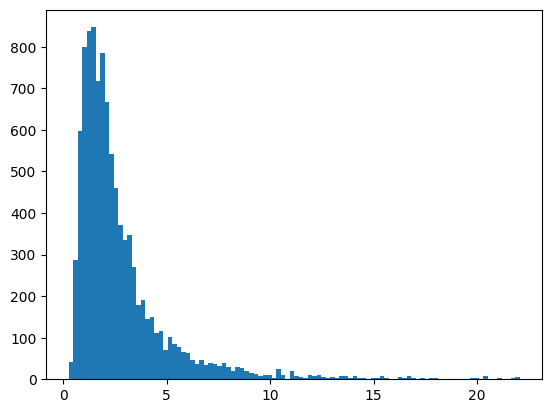

In [6]:
train_df = train_df[train_df['consumption_per_capita_per_day'] < 25]
plt.hist(train_df['consumption_per_capita_per_day'], bins=100)

In [17]:
datawrapperpath = 'pickled/datawrapper-maxepochs=3000_lr=0.001_batchsize=256_dropout=0.1.pickle'
generatorpath = 'pickled/generator-maxepochs=3000_lr=0.001_batchsize=256_dropout=0.1.pickle'
f = get_wgan_data_generator(generatorpath, datawrapperpath)

In [14]:
train_df = f(10000, seed=582645)
val_df = f(50000, seed=1)
train_dataset = Dataset(train_df, outcome="consumption_per_capita_per_day", covs=[], weight="hh_wgt")
val_dataset = Dataset(val_df, outcome="consumption_per_capita_per_day", covs=[], weight="hh_wgt")

In [4]:
ordered_features, _ = forward_selection(train_dataset, val_dataset)

log_yearly_rent 0.17250720403162245
popdensity 0.23560034970249544
afmnslp_pct 0.27924811436706554
num_children 0.3067160024061134
h2019_tot 0.3183642751635398
h2018_wetQstart 0.32960769488033403
h2018_ndvi_max 0.3439810833913399
hhsize 0.35506531256930984
wetQ_avgstart 0.3627292679534224
ea_lon_mod 0.3724825416936689
wetQ_avg 0.3795727568161663
dist_road 0.3837302874838857
twi_mwi 0.38861778036913197
af_bio_1_x 0.39170280714921246
sq7 0.39520004821816124
hh_x03 0.39783679557426666
durable_asset_Bed 0.39997474796520527
ndvi_avg 0.402244725897151
h2019_ndvi_max 0.40528469786709387
sq2 0.4075919851049087
area 0.40939832743491544
anntot_avg 0.41113392089463074
durable_asset_Mortar/pestle (mtondo) 0.4129206427046892
srtm_1k 0.4146335802651685
sq1 0.4162775579223723
h2018_ndvi_avg 0.41761180863160174
num_adults 0.4189601708977092
cropshare 0.4201095542506553
h2018_tot 0.42132383534445883
h2018_wetQ 0.42234857643442103
dist_agmrkt 0.42350028413312846
dist_popcenter 0.4249632520413841
h2019_w

In [29]:
ds = [0]
n_bins= [5, 10, 20, 50, 100]
n_knots= [2, 4, 8, 10, 12]
degree= [2, 3, 4, 5]

for d in ds:
    train_dataset = Dataset(train_df, outcome="consumption_per_capita_per_day", covs=ordered_features[:d], weight="hh_wgt")
    val_dataset = Dataset(train_df, outcome="consumption_per_capita_per_day", covs=ordered_features[:d], weight="hh_wgt")
    estimator = get_cond_density_estimator(train_dataset)
    
    nll = get_nll(val_dataset, estimator)
    print(nll)

NameError: name 'ordered_features' is not defined

Fitting conditional densities vs glm spline method...


100%|██████████| 300/300 [00:01<00:00, 222.32it/s, loss=-0.0722, val_loss=-0.059] 


Final Theta: tensor([[-2.7166],
        [ 1.5891],
        [-0.3539],
        [ 0.3781],
        [-0.0258],
        [ 1.4636]], dtype=torch.float64)
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 5.02426495e-01 4.61312191e-01 4.20197886e-01
 3.79083582e-01 3.37969277e-01 2.96854973e-01 2.55740668e-01
 2.14626364e-01 1.73512060e-01 1.52772592e-01 1.46586581e-01
 1.40400569e-01 1.34214557e-01 1.28028545e-01 1.21842533e-01
 1.15656521e-01 1.09470509e-01 1.03284497e-01 9.97646913e-02
 9.99775734e-02 1.00190455e-01 1.00403337e-01 1.00616220e-01
 1.00829102e-01 1.01041984e-01 1.01254866e-01 1.01467748e-01
 1.01407914e-01 1.00529934e-01 9.96519541e-02 9.87739740e-02
 9.78959940e-02 9.70180139e-02 9.61400339e-02 9.52620538e-02
 9.43840737e-02 9.33397564e-02 9.04657286e-02 8.75917008e-02
 8.47176730e-02 8.18436452e-02 7.89696174e-02 7.60955896e-02
 7.32215618e-02 7.03475340e-02 6.74735062e-02 6.52269858e-

(array([2.54386003e-01, 1.28196497e-01, 1.08001142e-01, 6.79868019e-02,
        3.67530018e-02, 1.85646562e-02, 8.40427256e-03, 3.63767021e-03,
        1.12893146e-03, 1.25436904e-04]),
 array([ 0.        ,  1.59442735,  3.18885469,  4.78328228,  6.37770939,
         7.97213697,  9.56656456, 11.16099167, 12.75541878, 14.34984684,
        15.94427395]),
 <BarContainer object of 10 artists>)

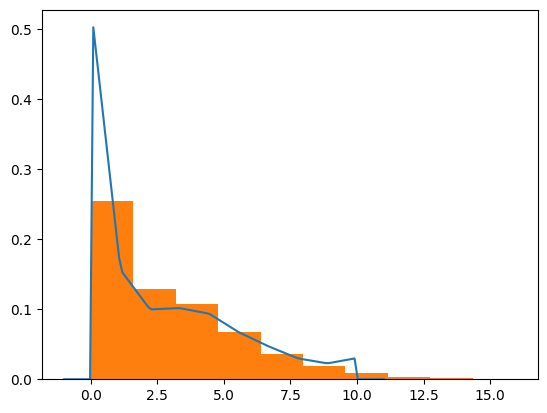

In [32]:
import numpy as np
import matplotlib.pyplot as plt
train_dataset = Dataset(train_df, outcome="consumption_per_capita_per_day", covs=[], weight="hh_wgt")
estimator = get_cond_density_estimator(train_dataset, n_bins=10)
X,y, r = train_dataset.get_data()
cond_dists = estimator(X)
print(cond_dists[0].pdf(np.linspace(-1, 11, 100)))

plt.plot(np.linspace(-1, 11, 100), cond_dists[0].pdf(np.linspace(-1, 11, 100)))
plt.hist(y,density=True, bins=10)



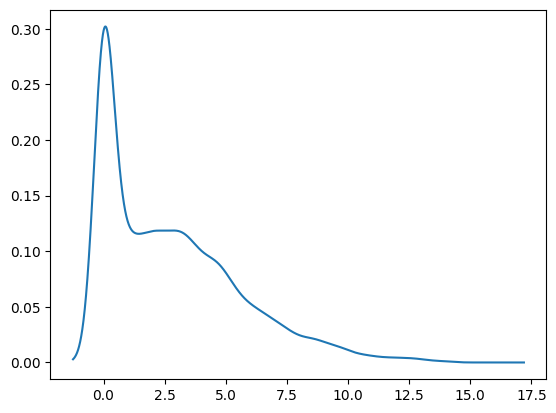

In [24]:
from statsmodels.nonparametric.kde import KDEUnivariate
kde = KDEUnivariate(y)
kde.fit(weights=r, fft=False, adjust=0.8)
plt.plot(kde.support, kde.density)

In [11]:
np.log(cond_dists[0].pdf(np.linspace(0., 10, 100)))

array([-0.12533396, -0.27318234, -0.47107558, -0.71079325, -0.97964453,
       -1.25950079, -1.52763958, -1.76118096, -1.94454251, -2.07483411,
       -2.16026244, -2.21353552, -2.24602258, -2.26583711, -2.27819195,
       -2.28627813, -2.29199216, -2.2964004 , -2.30003807, -2.30312162,
       -2.30569715, -2.307721  , -2.30907044, -2.3094988 , -2.30857154,
       -2.30564183, -2.29993027, -2.29074286, -2.27778666, -2.26145904,
       -2.24295644, -2.22411671, -2.20704155, -2.19365231, -2.18534535,
       -2.1828409 , -2.18621925, -2.19506646, -2.20854287, -2.22537479,
       -2.24412112, -2.26329875, -2.28155532, -2.29793399, -2.31215466,
       -2.32476928, -2.33706747, -2.35071928, -2.36727265, -2.3876873 ,
       -2.41206324, -2.43964907, -2.46913034, -2.49910753, -2.52858733,
       -2.55728153, -2.58558924, -2.61431203, -2.64430029, -2.67624057,
       -2.71066021, -2.74805007, -2.78891246, -2.83359753, -2.88195977,
       -2.93303447, -2.98499407, -3.03555039, -3.08273626, -3.12

(array([4348., 2254., 1715., 1009.,  432.,  165.,   46.,   20.,    6.,
           5.]),
 array([ 0.        ,  1.84851873,  3.69703746,  5.54555607,  7.39407492,
         9.24259377, 11.09111214, 12.93963146, 14.78814983, 16.63666916,
        18.48518753]),
 <BarContainer object of 10 artists>)

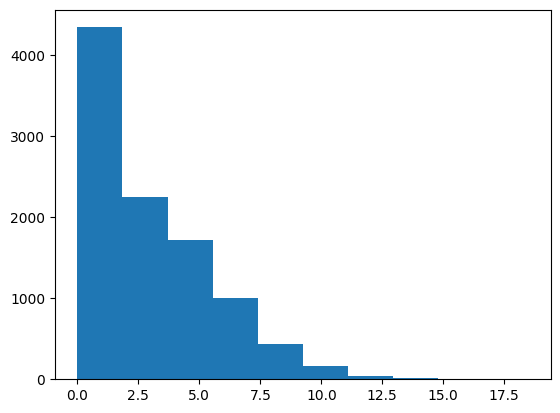

In [19]:
train_df = f(5000, seed=582645)
X_train, y_train, r_train = train_dataset.get_data()
plt.hist(y_train)

(array([2.3192e+04, 1.2268e+04, 8.3320e+03, 4.0140e+03, 1.5360e+03,
        4.6800e+02, 1.3200e+02, 4.7000e+01, 1.0000e+01, 1.0000e+00]),
 array([ 0.        ,  2.04746366,  4.09492731,  6.14239073,  8.18985462,
        10.23731804, 12.28478146, 14.33224487, 16.37970924, 18.42717171,
        20.47463608]),
 <BarContainer object of 10 artists>)

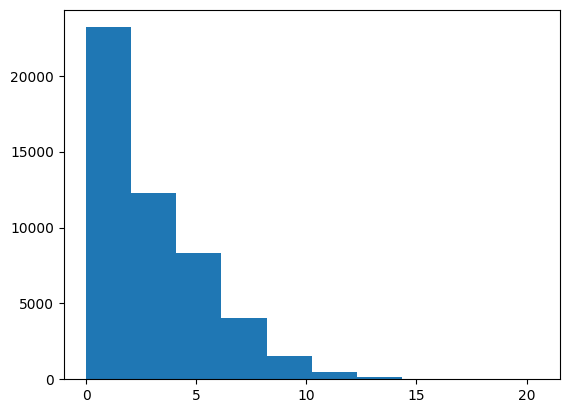

In [28]:
X_val, y_val, r_val = val_dataset.get_data()
plt.hist(y_val, bins=10)